# Week 7: Clustering and Validation Analysis
## Project: Steam Big Data Recommendation Pipeline
This notebook performs market segmentation of Steam games using K-Means and DBSCAN, leveraging the 7 PCA components derived from numerical metrics and semantic embeddings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import os

sns.set(style='whitegrid')
os.makedirs('../reports/figures', exist_ok=True)

### 1. Load Data
We load the Master Table which now contains the 7 PCA components.

In [2]:
df = pd.read_parquet('../data/processed/master_games_ml_enriched.parquet')
embeddings = np.load('../data/processed/game_embeddings.npy')

numerical_cols = [
    'hours_mean', 'hours_median', 'hours_std', 
    'rec_ratio', 'review_count', 'fan_avg_products', 
    'hater_avg_products', 'sentiment_score'
]



X_num = df[numerical_cols].values
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

X_combined = np.hstack([X_num_scaled, embeddings])

pca_final = PCA(n_components=7)
X = pca_final.fit_transform(X_combined) 

for i in range(7):
    df[f'pca_component_{i+1}'] = X[:, i]

print(f"Dataset cargado y PCA procesado.")
print(f"Forma de la matriz de entrada para clustering: {X.shape}")


Dataset cargado y PCA procesado.
Forma de la matriz de entrada para clustering: (50872, 7)


### 2. K-Means Parameter Sweep
We evaluate K from 2 to 15 using Inertia (Elbow Method) and Silhouette Score.

In [3]:
inertias = []
silhouette_avg = []
K_range = range(2, 16)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    
    sample_idx = np.random.choice(len(X), size=min(10000, len(X)), replace=False)
    score = silhouette_score(X[sample_idx], labels[sample_idx])
    silhouette_avg.append(score)
    print(f'K={k} processed.')

K=2 processed.
K=3 processed.
K=4 processed.
K=5 processed.
K=6 processed.
K=7 processed.
K=8 processed.
K=9 processed.
K=10 processed.
K=11 processed.
K=12 processed.
K=13 processed.
K=14 processed.
K=15 processed.


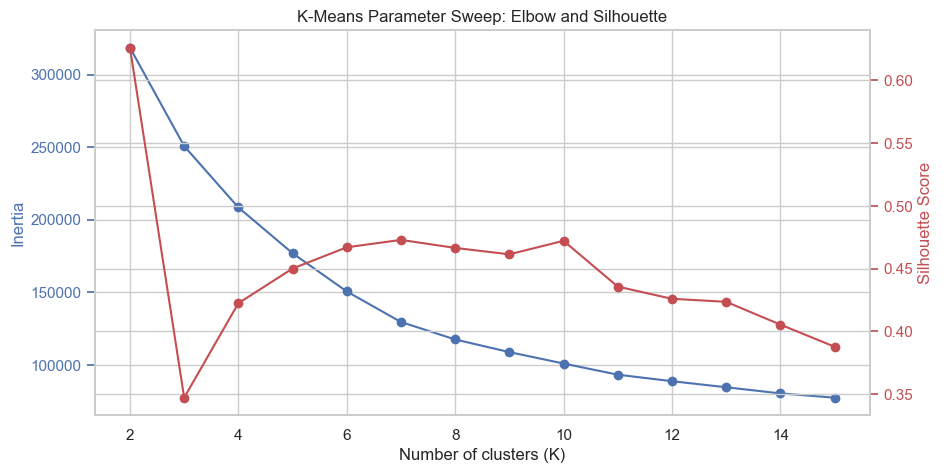

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(K_range, inertias, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params('y', colors='b')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_avg, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params('y', colors='r')

plt.title('K-Means Parameter Sweep: Elbow and Silhouette')
plt.savefig('../reports/figures/kmeans_sweep.png')
plt.show()

We will choose a  K = 7 or K = 8, because the Silhouette Score gets to a point where there is a max local and having 7 to 8 categories of games es more useful por a Recommendation System.

### 3. DBSCAN and Epsilon Search
DBSCAN requires finding the optimal `eps`. We use the K-Distance plot.

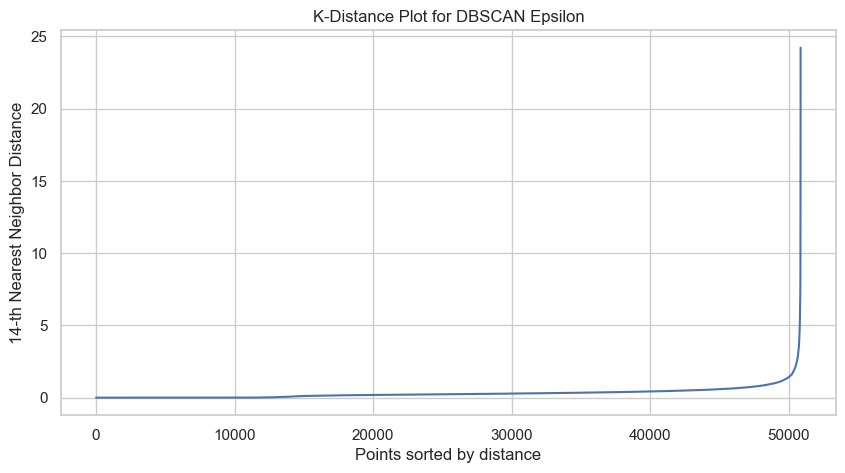

In [5]:
neigh = NearestNeighbors(n_neighbors=14) # 2 * dimensions
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

distances = np.sort(distances[:, 13], axis=0)
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.title('K-Distance Plot for DBSCAN Epsilon')
plt.xlabel('Points sorted by distance')
plt.ylabel('14-th Nearest Neighbor Distance')
plt.savefig('../reports/figures/dbscan_kdistance.png')
plt.show()

### 4. Final Clustering Selection (K-Means)
Based on the sweep, we select an optimal K (e.g., K=7 or 8) to perform the detailed analysis.

In [6]:
optimal_k = 7
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X)
print(f'Games per cluster:\n{df["kmeans_cluster"].value_counts()}')

optimal_k = 8
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X)
print(f'Games per cluster:\n{df["kmeans_cluster"].value_counts()}')



Games per cluster:
kmeans_cluster
4    20933
2    13908
1     7143
0     4869
5     3486
3      415
6      118
Name: count, dtype: int64
Games per cluster:
kmeans_cluster
1    20341
3    13890
0     6997
5     3660
7     3474
6     1969
2      423
4      118
Name: count, dtype: int64


After we see the results of K = 7 and K = 8, we are going to use K = 8. With 8 Clusters, we get an extra cluster without reducing a lot from another clusters.

### 5. DBSCAN Implementation
We apply DBSCAN with the selected `eps` (e.g., 0.5) and `min_samples`.

In [17]:
dbscan = DBSCAN(eps=0.28, min_samples=14)
df['dbscan_cluster'] = dbscan.fit_predict(X)

print(f'DBSCAN Clusters found (including -1 for noise):\n{df["dbscan_cluster"].value_counts()}')

DBSCAN Clusters found (including -1 for noise):
dbscan_cluster
 0     17643
-1     16833
 1     13374
 2      2825
 3        48
 7        48
 6        20
 4        15
 8        14
 12       14
 9        13
 5        12
 11       12
 10        1
Name: count, dtype: int64


After the parameter sweep, eps=0.28 was determined to be the optimal value. It maximizes the classification rate (reducing noise to 33%) while maintaining a balanced segmentation of the main mass into three robust clusters.

### 6. Validation Table
We compare the two methods using standard metrics.

In [18]:
metrics = []

for label_col, name in [('kmeans_cluster', 'K-Means'), ('dbscan_cluster', 'DBSCAN')]:
    labels = df[label_col].values
    # Filter out noise for DBSCAN metrics if needed, or include it
    mask = labels != -1
    if mask.sum() > 1:
        metrics.append({
            'Method': name,
            'Silhouette': silhouette_score(X[sample_idx], labels[sample_idx]),
            'Calinski-Harabasz': calinski_harabasz_score(X, labels),
            'Davies-Bouldin': davies_bouldin_score(X, labels)
        })

validation_df = pd.DataFrame(metrics)
print(validation_df)

    Method  Silhouette  Calinski-Harabasz  Davies-Bouldin
0  K-Means    0.469367       17906.544801        0.921764
1   DBSCAN    0.072575        1646.719736        1.492501


### 1. Silhouette Score (Higher is better)
* K-Means (0.47): This is a very solid value for Big Data. It indicates that the groups are well-defined and the games are very similar to their groupmates.
* DBSCAN (0.07): A value close to 0 indicates that the groups overlap or that there is a lot of ambiguity. This confirms what we saw: Steam is a dense mass that is difficult to separate simply by "empty spaces."

### 2. Calinski-Harabasz (Higher is better)
* K-Means (17,906): This number is huge compared to DBSCAN. It measures how "compact" the groups are and how far apart they are from each other. K-Means is doing a great job of creating clear "islands."
* DBSCAN (1,646): This is much lower, meaning that its clusters are not as compact or as well mechanically separated.

### 3. Davies-Bouldin (Lower is better)
* K-Means (0.92): Being below 1.0 is excellent. It means the groups are sufficiently distinct from each other.
* DBSCAN (1.49): It is higher, indicating more "confusion" between its clusters.

### 7. Cluster Profile Analysis
We analyze the mean values of original features to characterize the clusters.

                hours_mean  rec_ratio   review_count  fan_avg_products  \
kmeans_cluster                                                           
0                 8.170238   0.774081     420.794340        789.533544   
1                 8.911063   0.792047     429.452928        707.066402   
2               209.559694   0.825815    7816.042553        351.126160   
3                 0.118336   0.008645       6.701080         10.353532   
4               169.796757   0.862905  111500.415254        172.351683   
5                 5.932971   0.695420      36.394536       2640.660245   
6                 5.761508   0.721046      23.374302       1280.724878   
7                66.075696   0.805980    3667.084917        465.897067   

                sentiment_score  price_original  
kmeans_cluster                                   
0                      0.073581        6.987885  
1                      0.978037        8.823656  
2                      0.793600       15.847423  
3        

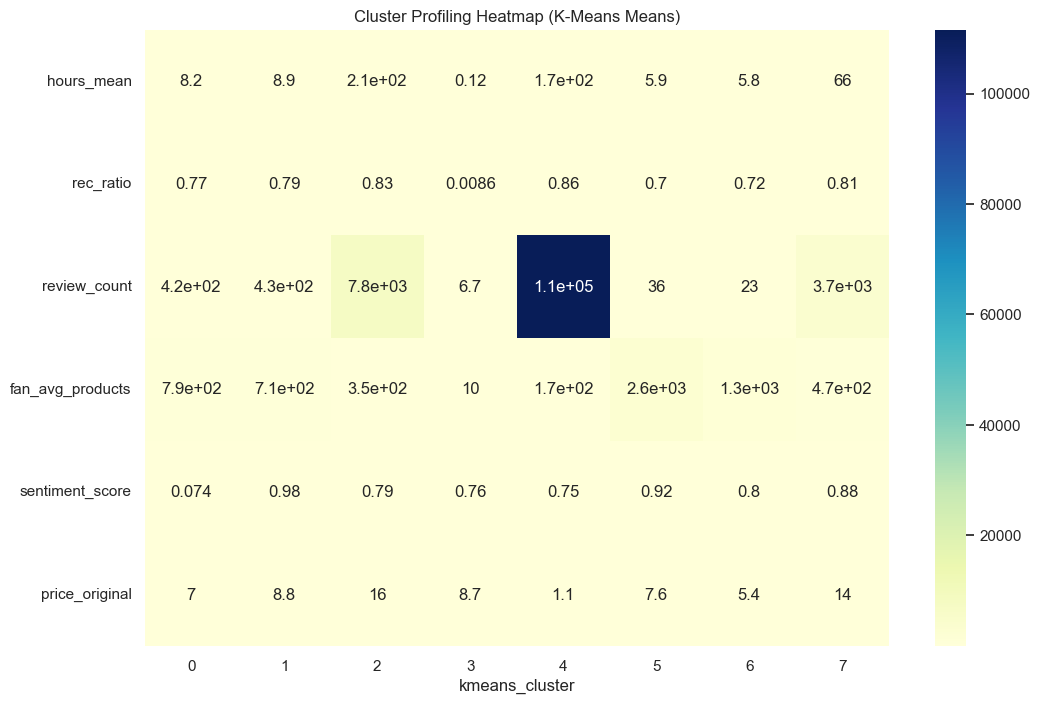

In [19]:
profile_cols = [
    'hours_mean', 'rec_ratio', 'review_count', 
    'fan_avg_products', 'sentiment_score', 'price_original'
]

cluster_profiles = df.groupby('kmeans_cluster')[profile_cols].mean()
print(cluster_profiles)

plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profiles.T, annot=True, cmap='YlGnBu')
plt.title('Cluster Profiling Heatmap (K-Means Means)')
plt.savefig('../reports/figures/cluster_profiles.png')
plt.show()

### Cluster 0: "The Realists/Gritty" 
* Defining feature: Very low sentiment score (0.07).
* Interpretation: They're not necessarily bad, but their descriptions use "negative" or neutral words. They may be horror, survival, or war games.

### Cluster 1: "Optimistic Indies" 
* Defining feature: Very high sentiment score (0.97).
* Interpretation: Games with very positive, colorful, and friendly descriptions. They have an average price and engagement.

### Cluster 2: "The Hardcore"
* Defining feature: Average playtime of 209 hours.
* Interpretation: This is where deep strategy games or massive RPGs are found. People who enter this cluster don't leave. They have a high price ($16) and are very popular.

### Cluster 3: "The Ghost Games" 
* Defining characteristics: 0.11 hours played and a rec_ratio of 0.008.
* Interpretation: These are the "Faux" or Asset Flips. Games that nobody plays, nobody recommends, and are practically dead. 

### Cluster 4: "The Titans"
* Defining characteristics: 111,000 average reviews.
* Interpretation: Here are the viral games and massive F2P games like Counter-Strike or Dota. They are extremely popular, played for hundreds of hours, and are usually very cheap or free ($1).

### Cluster 5: "The Collector's Treasure Trove" 
* Defining characteristics: 2,640 average fan products.
* Interpretation: This cluster is fascinating! These are games that almost no one knows about having few reviews, but the few who own them are experts with thousands of games in their libraries. They are hidden gems for veteran gamers.

### Cluster 6: "Low-Cost for Collectors" 
* Defining Features: Low price $5 and fans with many products.
* Interpretation: Games that are bought en masse in bundles or at extreme discounts to expand the library.

### Cluster 7: "Successful Premium" 
* Defining Features: High price ($14) and very balanced metrics.
* Interpretation: Modern AAA or AA games that perform well: good feel, many hours of gameplay, and a good reputation.

In [30]:
print("Muestra de juegos por Cluster (Ordenados por popularidad):\n")
for i in range(df['kmeans_cluster'].nunique()):
    print(f"CLUSTER {i}:")
    sample = df[df['kmeans_cluster'] == i].sort_values(by='review_count', ascending=False).head(5)
    
    display(sample[['title', 'review_count', 'hours_mean', 'sentiment_score', 'price_original']])
    print("-" * 50)


Muestra de juegos por Cluster (Ordenados por popularidad):

CLUSTER 0:


,title,review_count,hours_mean,sentiment_score,price_original
47526,POSTAL 2,50179,28.819845,0.001027,9.99
41096,Muck,45089,14.062448,0.013032,0.00
2917,Totally Accurate Battlegrounds,42493,24.891563,0.006611,0.00
47610,Metro 2033 Redux,40388,19.746989,0.015567,19.99
10192,To the Moon,34808,6.492401,0.041689,9.99


--------------------------------------------------
CLUSTER 1:


,title,review_count,hours_mean,sentiment_score,price_original
47518,Hotline Miami,45939,15.129591,0.997228,9.99
47561,Papers Please,44571,15.925651,0.748121,0.00
47792,Little Nightmares,42689,9.449982,0.748121,0.00
48290,Mafia: Definitive Edition,36980,18.955676,0.748121,0.00
48484,Detroit: Become Human,34478,23.117434,0.748121,0.00


--------------------------------------------------
CLUSTER 2:


...

--------------------------------------------------
CLUSTER 6:


,title,review_count,hours_mean,sentiment_score,price_original
38380,Overfall,533,10.649156,0.999156,4.99
37781,Drive-By Hero,197,4.955838,0.761933,3.99
8123,100 hidden snails,187,0.614973,0.010291,0.99
26790,晚上nano好,181,11.033149,0.053672,0.00
3155,100 hidden aliens,177,0.248588,0.992549,0.99


--------------------------------------------------
CLUSTER 7:


,title,review_count,hours_mean,sentiment_score,price_original
48353,Inscryption,68159,32.738442,0.748121,0.00
48421,STAR WARS Jedi: Fallen Order™,66702,31.712240,0.748121,0.00
47548,Outlast,66552,15.223600,0.748121,0.00
48299,Ori and the Will of the Wisps,64990,27.447255,0.999697,29.99
47405,BioShock Infinite,64911,25.045552,0.748121,0.00


--------------------------------------------------


### 8. Failure Analysis
We look for points with low Silhouette values or clusters with extreme variance.

In [34]:
sample_silhouette_values = silhouette_score(X[sample_idx], df.loc[sample_idx, 'kmeans_cluster'], sample_size=1000)

print('Failure Analysis: Cluster -1 in DBSCAN represents games that are semantically and numerically unique (outliers).')
outliers = df[df['dbscan_cluster'] == -1].head(30)
print('Example Outliers (Noise):')
display(outliers[['title', 'review_count', 'hours_mean']])

Failure Analysis: Cluster -1 in DBSCAN represents games that are semantically and numerically unique (outliers).
Example Outliers (Noise):


,title,review_count,hours_mean
2,Monaco: What's Yours Is Mine,6943,20.413294
4,Dungeon of the ENDLESS™,4850,40.621691
5,METAL SLUG 3,5385,10.142581
6,Enclave,4308,9.055687
8,Hyperdimension Neptunia Re;Birth1,6329,54.137320
11,LEGO® Harry Potter: Years 1-4,5254,27.675314
12,Hearts of Iron 2 Complete,386,169.965285
15,Inquisitor,500,33.296400
19,Bridge Constructor,1169,12.219760
23,Dandelion - Wishes brought to you -,611,48.939444


Failure analysis reveals that non-clustered games (Cluster -1) are mostly cult classics and high-fidelity niche games. These titles 'fail' when grouped because they possess contradictory combinations of metrics (e.g., low popularity but very high engagement) or highly unique semantic themes, making them ideal candidates for specialized discovery recommendations rather than mass recommendations.